# Grad-CAM Visualization Module

Purpose: Explainability and model interpretation for recyclability predictions

Technique: Gradient-weighted Class Activation Mapping (Grad-CAM)

Backbone Model: EfficientNetB0

Last Convolutional Layer: top_conv

Output: Heatmap highlighting image regions that most influenced the model's prediction

What's included in this section:

1. Grad-CAM heatmap generation
2. Extraction of feature maps from the final convolutional layer
3. Gradient computation for the predicted class
4. Heatmap normalization and visualization
5. Overlay of heatmap on the original image
6. Visual explanation of recyclable predictions
7. Visual explanation of unrecyclable predictions
8. Single-image explainability function
9. Model interpretability analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import tensorflow as tf

SOURCE_PATH = "/content/drive/MyDrive/grad model/recyclability_model_v2.keras.zip"
TARGET_PATH = "/content/recyclability_model_v2.keras"

shutil.copy(SOURCE_PATH, TARGET_PATH)

model = tf.keras.models.load_model(TARGET_PATH, compile=False)

print("MODEL LOADED SUCCESSFULLY")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODEL LOADED SUCCESSFULLY


In [ ]:
IMG_SIZE = (224, 224)

CLASS_NAMES = ["recyclable", "unrecyclable"]

RECYCLABLE_IDX = 0
UNRECYCLABLE_IDX = 1

THRESHOLD = 0.5

In [ ]:
for layer in model.layers:
    print(layer.name)

input_image
augmentation
efficientnetb0
gap
batch_normalization
dense_256
dropout
dense_64
dropout_1
output


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image

IMG_SIZE = (224, 224)
CLASS_NAMES = ["recyclable", "unrecyclable"]
THRESHOLD = 0.5

def gradcam_recyclability(img_path):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img)
    img_input = np.expand_dims(img_array, axis=0)

    augmentation = model.get_layer("augmentation")
    efficientnet = model.get_layer("efficientnetb0")
    gap = model.get_layer("gap")
    batch_norm = model.get_layer("batch_normalization")
    dense_256 = model.get_layer("dense_256")
    dropout = model.get_layer("dropout")
    dense_64 = model.get_layer("dense_64")
    dropout_1 = model.get_layer("dropout_1")
    output_layer = model.get_layer("output")

    with tf.GradientTape() as tape:
        x = augmentation(img_input, training=False)

        conv_outputs = efficientnet(x, training=False)
        tape.watch(conv_outputs)

        x = gap(conv_outputs)
        x = batch_norm(x, training=False)
        x = dense_256(x)
        x = dropout(x, training=False)
        x = dense_64(x)
        x = dropout_1(x, training=False)
        predictions = output_layer(x)

        raw_prob = predictions[:, 0]

        pred_class = int(raw_prob.numpy()[0] > THRESHOLD)

        if pred_class == 1:
            loss = raw_prob
        else:
            loss = 1 - raw_prob

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    raw_prob_value = float(raw_prob.numpy()[0])
    pred_label = CLASS_NAMES[pred_class]

    if pred_class == 1:
        confidence = raw_prob_value
    else:
        confidence = 1 - raw_prob_value

    print("Prediction:", pred_label)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("Raw probability:", round(raw_prob_value, 4))

    original = np.array(img).astype(np.uint8)

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Prediction: recyclable
Confidence: 99.99 %
Raw probability: 0.0001


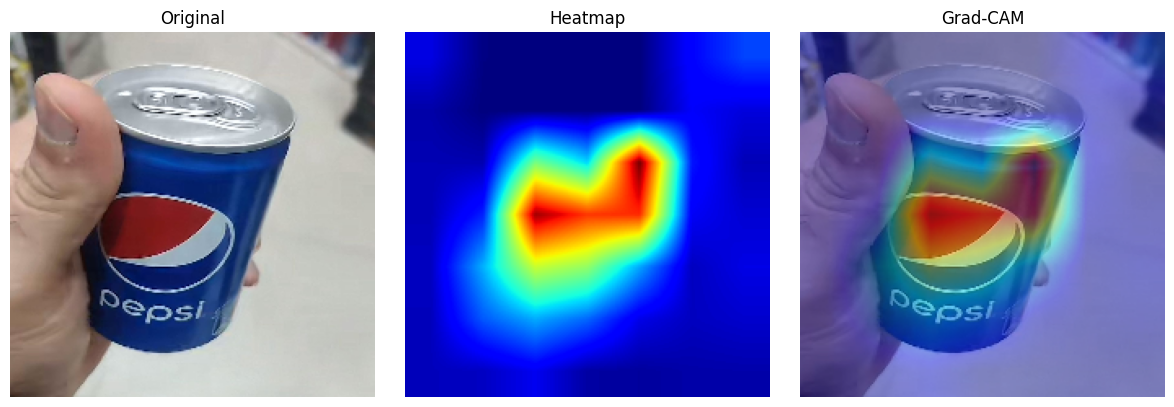

In [ ]:
gradcam_recyclability("/content/samplemetal3.jpg")

Prediction: unrecyclable
Confidence: 99.93 %
Raw probability: 0.9993


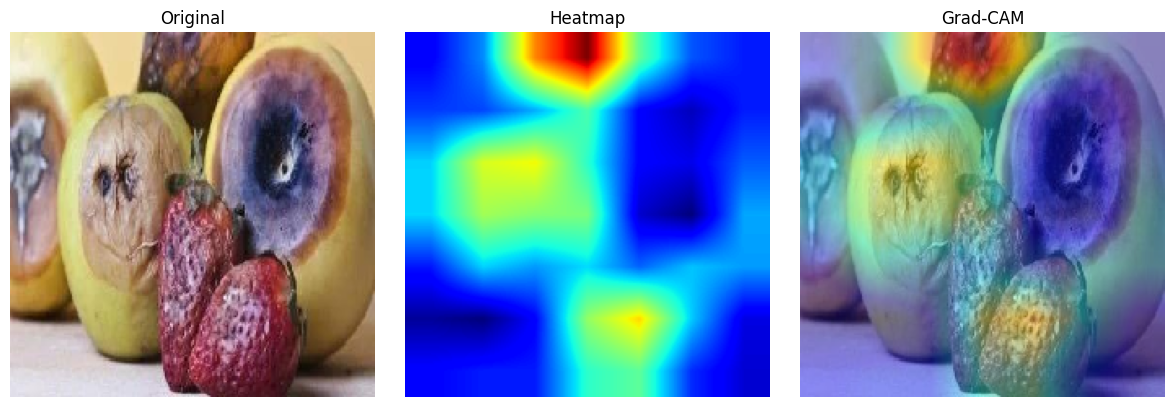

In [ ]:
gradcam_recyclability("/content/test.jpeg")